<a href="https://colab.research.google.com/github/jpnoug/spectropy/blob/main/visualisation_spectre_T_CrB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook Colab : Plot du spectre de T CrB (Alpy 600)
### Instructions :
1. Téléchargez votre fichier FITS (ex: `t_crb_alpy600.fits`) dans Colab via l'icône 📁 à gauche.
2. Exécutez toutes les cellules dans l'ordre.
3. Adaptez les paramètres dans la cellule 'Chargement du FITS' si nécessaire.

In [2]:
!pip install astropy matplotlib numpy scipy photutils -q

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from scipy.signal import find_peaks, medfilt
from google.colab import files  # <-- AJOUT POUR LE TÉLÉCHARGEMENT
import warnings
warnings.filterwarnings('ignore')

# Configuration des graphiques
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

In [6]:
# ⬇️ MODIFIEZ CES PARAMÈTRES ⬇️
filename = '_t_crb_20260529_944_JPN.fits'  # Remplacez par votre fichier
extension = 0  # Extension FITS (0, 1, ou 'PRIMARY')
wavelength_unit = 'angstrom'  # Votre fichier est en angstrom

# Chargement du FITS
with fits.open(filename) as hdul:
    data = hdul[extension].data
    header = hdul[extension].header

    # Extraction du spectre
    if data.ndim == 1:
        flux = data
    elif data.ndim == 2:
        flux = np.nanmean(data, axis=0)

    # Extraction de la calibration en longueur d'onde
    wcs = WCS(header)
    wavelengths = wcs.all_pix2world(np.arange(len(flux)), 0)[0]

    # Extraction de la date d'observation (DATE-OBS ou DATE)
    obs_date = header.get('DATE-OBS', header.get('DATE', 'Date inconnue'))
    print(f"Date d'observation : {obs_date}")

    print(f"✅ Fichier chargé : {filename}")
    print(f"   Plage spectrale : {wavelengths.min():.1f} - {wavelengths.max():.1f} {wavelength_unit}")

Date d'observation : 2026-05-29T22:39:53
✅ Fichier chargé : _t_crb_20260529_944_JPN.fits
   Plage spectrale : 3560.5 - 7380.0 angstrom


In [7]:
# Prétraitement
window_size = 3
smoothed_flux = np.convolve(flux, np.ones(window_size)/window_size, mode='same')
normalized_flux = (smoothed_flux - np.nanmin(smoothed_flux)) / (np.nanmax(smoothed_flux) - np.nanmin(smoothed_flux))
continuum = medfilt(normalized_flux, kernel_size=51)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

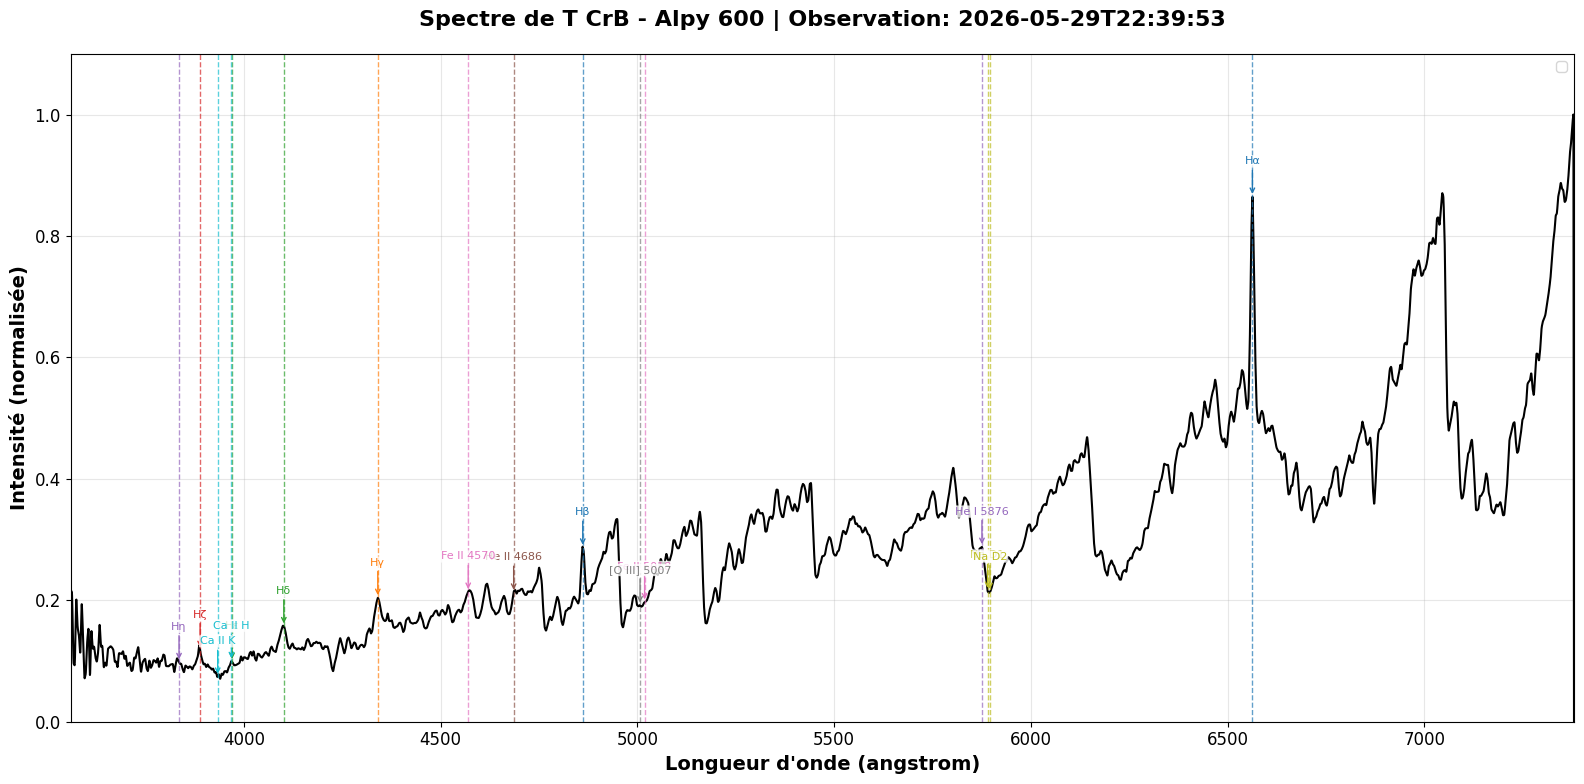

In [9]:
import os
file_label = os.path.basename(filename)

# ⬇️ PARAMÈTRES ⬇️
show_balmer_only = False
wavelength_range = (3560, 7380)
wavelength_unit = 'angstrom'

# Sélection des raies (EN ANGSTROM)
lines_to_plot = {
    'Hα': 6562.8, 'Hβ': 4861.3, 'Hγ': 4340.5,
    'Hδ': 4101.7, 'Hε': 3970.1, 'Hζ': 3889.0, 'Hη': 3835.4,
    'He I 5876': 5875.6, 'He II 4686': 4685.7,
    'Fe II 4570': 4570.2, 'Fe II 5018': 5018.4,
    '[O III] 5007': 5006.8, 'Na D1': 5889.9, 'Na D2': 5895.9,
    'Ca II H': 3968.5, 'Ca II K': 3933.7
}

visible_lines = {name: wl for name, wl in lines_to_plot.items()
                 if wavelength_range[0] <= wl <= wavelength_range[1]}

# Graphique
fig, ax = plt.subplots(figsize=(16, 8))
ax.plot(wavelengths, normalized_flux, color='black', linewidth=1.5, label=file_label)

# Annotation des raies
colors = plt.cm.tab10(np.linspace(0, 1, len(visible_lines)))
for (name, wl), color in zip(visible_lines.items(), colors):
    idx = np.argmin(np.abs(wavelengths - wl))
    y_pos = normalized_flux[idx]
    ax.axvline(x=wl, color=color, linestyle='--', alpha=0.7, linewidth=1)
    ax.annotate(
        name,
        xy=(wl, y_pos),
        xytext=(wl, y_pos + 0.05),
        arrowprops=dict(arrowstyle='->', color=color, lw=1),
        ha='center',
        va='bottom',
        color=color,
        fontsize=8,
        bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=0.8, ec='none')
    )

# Configuration
ax.set_xlim(wavelength_range)
ax.set_ylim(0, 1.1)
ax.set_xlabel(f'Longueur d\'onde ({wavelength_unit})', fontsize=14, fontweight='bold')
ax.set_ylabel('Intensité (normalisée)', fontsize=14, fontweight='bold')
ax.set_title(f'Spectre de T CrB - Alpy 600 | Observation: {obs_date}',
             fontsize=16, fontweight='bold', pad=20)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()

# ⬇️ ORDRE CORRIGÉ ⬇️
plt.savefig('spectre_t_crb.png', dpi=300, bbox_inches='tight', facecolor='white')
files.download('spectre_t_crb.png')
plt.show()  # Affiche le graphe à la fin